# Studying estimator properties

## Good estimator properties

According to statistical theory, a good estimator should have the following properties:

- **Unbiasedness**: The expected value of the estimator equals the true parameter value.

- **Consistency**: The estimator converges in probability to the true parameter as sample size increases.

- **Efficiency**: Among unbiased estimators, it achieves the minimum possible variance.


This Jupyter notedbook is dedicated to studying the unbiasedness, consistency and efficincy of the following estimators:

- $\mu = \frac{1}{n} \sum_{i=1}^{n} X_{i}$

- $s^2 = \frac{1}{n} \sum_{i=1}^{n} (X_{i}- \mu)^2$

- $s^{*2} = \frac{1}{n-1} \sum_{i=1}^{n} (X_{i}- \mu)^2$

First of all, a Standard Normal distribution with 100 bins is created, using 10000 random numbers that are distributed accoring to a Standard Normal distribution:

In [1]:
import matplotlib.pyplot as plt
import numpy as np

The mean value of the distribution is: -0.011951195575503918
The standard deviation of the distribution is: 0.9966231172604546


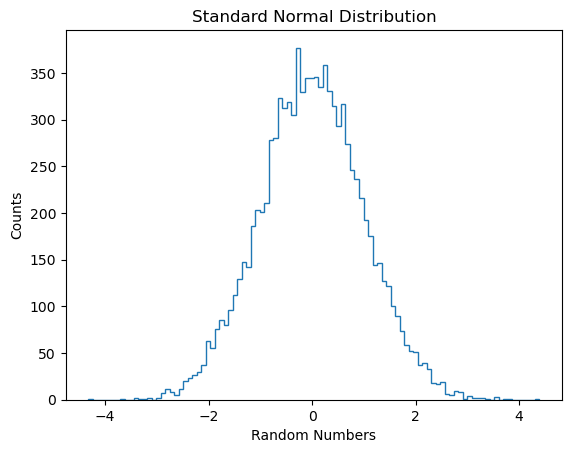

In [2]:
rands_g = np.random.randn(10000)
plt.hist(rands_g,bins=100,histtype='step')
plt.xlabel("Random Numbers")
plt.ylabel("Counts")
plt.title("Standard Normal Distribution")
print(f"The mean value of the distribution is: {np.mean(rands_g)}")
print(f"The standard deviation of the distribution is: {np.std(rands_g)}")

Next, 10000 random samples of size 5,10,100 are drawn from the Standard Normal distribution. Afterwards, the value of each estimator is computed from those samples and its distribution is plotted for each different size. Finally, conlcusions with respect to their unbiasedness, efficiency and consistency will be drawn. First of all, functions that accept Numpy arrays as arguments are constructed to compute each estimator:

In [3]:
def mean_estim(arr):
    
    """
    This function accepts as an argument a Numpy array.

    It calculates the sample mean and returns its value.
    """

    if len(arr) == 0:
        raise ZeroDivisionError("Your sample has zero size! Check your array definitions!")
    
    sum = np.sum(arr)
    
    return sum/len(arr)

In [ ]:
def variance_estim(arr, mode):

    """
    This function accepts as an arguments a Numpy array and an interger for the mode.

    It calculates the sample variance depnding on the mode inserted and returns its value.
    """

    mean = mean_estim(arr)
    sum = 0.0

    if len(arr) == 0:
        raise ZeroDivisionError("Your sample has zero size! Check your array definitions!")
    
    if mode == 2 and len(arr) == 1:
        raise ZeroDivisionError("You are going to divide with zero! Check your array definitions!")

    for i in range(len(arr)):
        sum += (arr[i] - mean)**2

    mode_to_val = {
        1: sum/(len(arr)),
        2: sum/(len(arr)-1)
    }
    
    if mode not in mode_to_val:
        raise ValueError("The mode you have inserted is invalid!")

    return mode_to_val[mode]


As a next step, a function that accepts as arguments a Numpy array and the size of the sample is created. This function will return a Numpy array with random values taken from the Standard Normal distribution, according to the sample size given by the user.

In [5]:
def get_rand(arr,sample_size):

    """
    This function accepts as an arguments a Numpy array and an interger for the sample size.

    It collects random numbers from the array, as many as the inserted sample size and returns
    a new Numpy array that contains them.
    """

    if sample_size <= 0:
        raise ValueError("The option you inserted for the sample size is invalid!")

    sample = np.random.choice(arr,size = sample_size)

    return sample

A function that will show the distribution, as well as a function that will return a Numpy array with the values of each estimator, according to the choice of the user.

In [6]:
def plot(arr,xtitle,title,nbins):

    """
    This function accepts as an arguments a Numpy array, an integer for the number of bins
    and two strings for the title and the X axis title.

    It plots the histogram according to the Numpy array that is inserted. It also print the
    mean value and the standard deviation of the histogram.
    """

    if nbins <= 0:
        raise ValueError("The number of bins you have inserted is invalid!")
    
    plt.hist(arr,nbins,histtype='step')
    plt.xlabel(xtitle)
    plt.ylabel("Counts")
    plt.title(title)

    print(f"The mean value of the distribution is: {np.mean(arr)}")
    print(f"The standard deviation of the distribution is: {np.std(arr)}")

def get_distr(arr,sample_size,estim,n_iter):

    """
    This function accepts as an arguments a Numpy array, an integer for the sample size and 
    and the number of iterations and one string for the name of the estimator.

    It gets n_iter samples of sample_size and calculates the value of the designated estimator
    for each sample. It returns the values of the estimaor as a Numpy array.
    """

    values = []

    print(f"Requested a sample of {sample_size} numbers!")

    if sample_size <= 0:
        raise ValueError("The option you inserted for the sample size is invalid!")

    if n_iter <= 0:
        raise ValueError("The number of iterations you have inserted is invalid!")
    
    print(f"Requested {n_iter} iterations!")

    str_to_func = {
        "mean": mean_estim,
        "var": lambda sample: variance_estim(sample,1),
        "star_var": lambda sample: variance_estim(sample,2)
    } 

    if estim not in str_to_func:
        raise ValueError(f"The estimator you have chosen is invalid!")

    for i in range(n_iter):
        sample = get_rand(arr,sample_size)
        val = str_to_func[estim](sample)
        values.append(val)
    
    estim_val = np.array(values)

    return estim_val

def get_full_plot(arr,sample_size,estim,xtitle,title,nbins,n_iter):

    """
    This function accepts assembles all the previously defined functions together.

    It plots the distribution of the estimator, using n_iter samples of sample_size.
    """

    try:
        values = get_distr(arr,sample_size,estim,n_iter)

        plot(values,xtitle,title,nbins)
    
    except (ValueError,ZeroDivisionError) as e:
        print(f"ERROR: {e}")


Below, the distributions of the estimator $\mu$ are shown, calculated from 10000 samples of 5,10 and 100 random numbers are shown:

Requested a sample of 5 numbers!
Requested 10000 iterations!
The mean value of the distribution is: -0.013507476360684069
The standard deviation of the distribution is: 0.44742926928892357


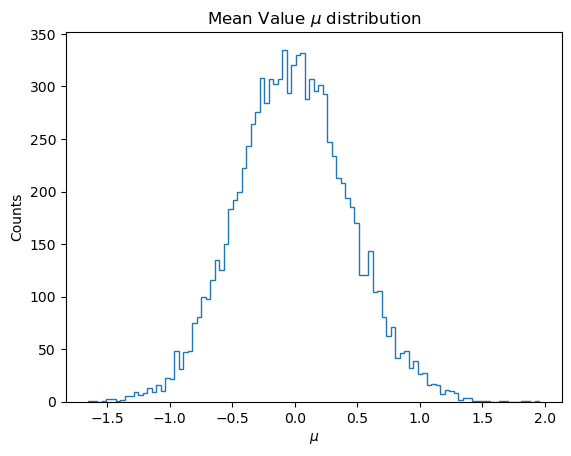

In [7]:

get_full_plot(rands_g,5,"mean","$\mu$","Mean Value $\mu$ distribution",100,10000)

Requested a sample of 10 numbers!
Requested 10000 iterations!
The mean value of the distribution is: -0.01242409952097839
The standard deviation of the distribution is: 0.31335473278152653


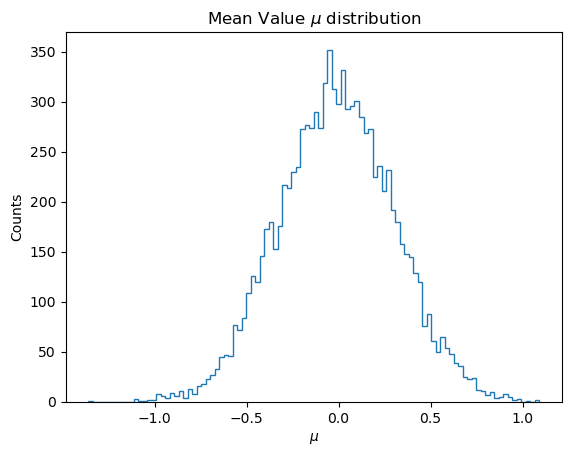

In [8]:
get_full_plot(rands_g,10,"mean","$\mu$","Mean Value $\mu$ distribution",100,10000)

Requested a sample of 100 numbers!
Requested 10000 iterations!
The mean value of the distribution is: -0.01153918376764024
The standard deviation of the distribution is: 0.09979940418360697


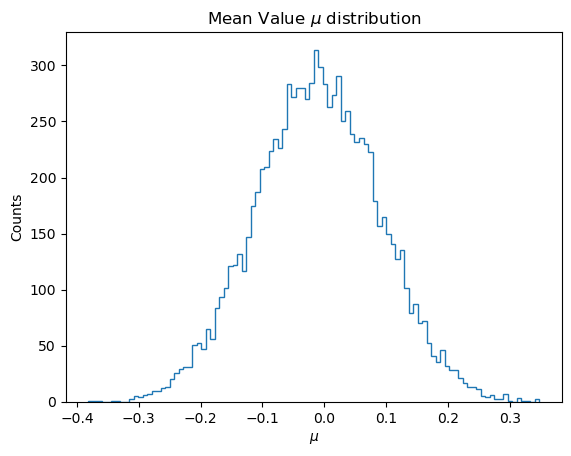

In [9]:
get_full_plot(rands_g,100,"mean","$\mu$","Mean Value $\mu$ distribution",100,10000)

**Conclusion**: It can be observed that right from the start, the mean value of the $\mu$ estimator's distribution is very close to the mean value of the initially generated distribution. It can also be seen that the size of the sample increases, which means that more values are used to calculate the value of the estimator, the mean value of the estimator's distribution tends to align with the mean value of the initially generated distribution. Finally, as the size of the sample increases, the variance of the estimator's distribution is decreasing. 

Therefore, the $\mu$ estimator is **unbiased**, **consistent** and more **efficient** as the size of the sample increases. Thus it is considered a good estimator.

Below, the distributions of the estimator $s^2$ are shown, calculated from 10000 samples of 5,10 and 100 random numbers are shown:

Requested a sample of 5 numbers!
Requested 10000 iterations!
The mean value of the distribution is: 0.7923052699627509
The standard deviation of the distribution is: 0.5776323635248363


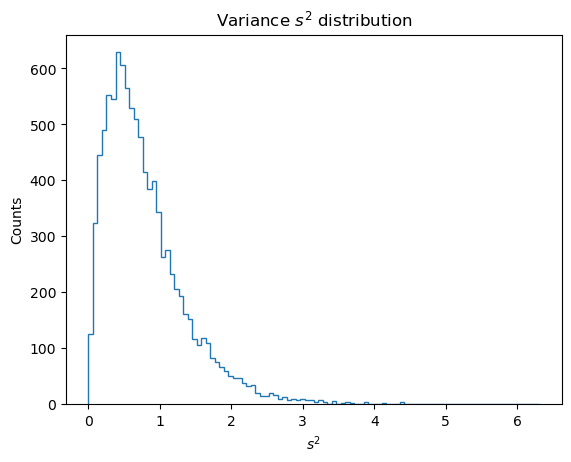

In [10]:
get_full_plot(rands_g,5,"var","$s^2$","Variance $s^2$ distribution",100,10000)

Requested a sample of 10 numbers!
Requested 10000 iterations!
The mean value of the distribution is: 0.8961576216628048
The standard deviation of the distribution is: 0.4259817678622459


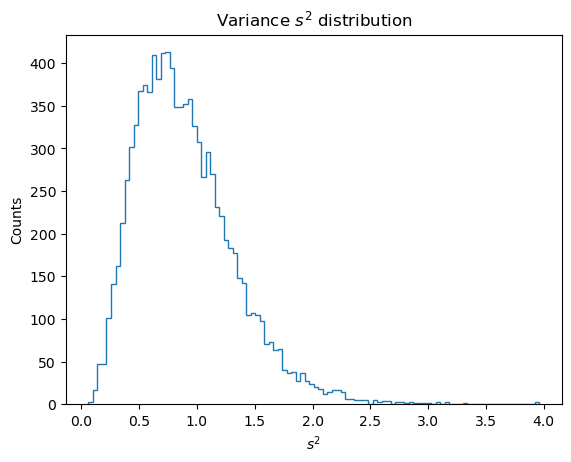

In [11]:
get_full_plot(rands_g,10,"var","$s^2$","Variance $s^2$ distribution",100,10000)

Requested a sample of 100 numbers!
Requested 10000 iterations!
The mean value of the distribution is: 0.9815074619412708
The standard deviation of the distribution is: 0.1405964465300581


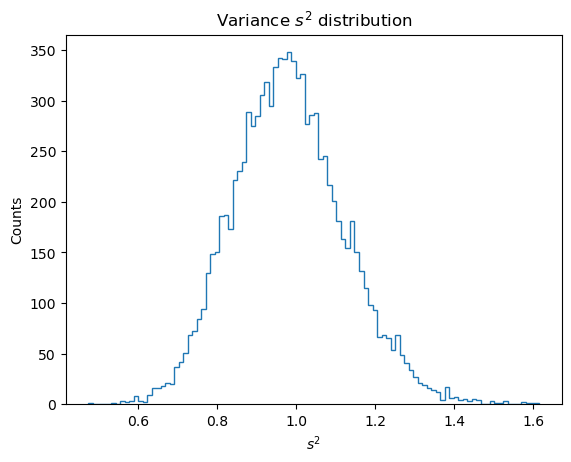

In [13]:
get_full_plot(rands_g,100,"var","$s^2$","Variance $s^2$ distribution",100,10000)

**Conclusion**: It can be observed that for the cases where the sample size is equal to 5 or 10, the mean value of the $s^2$ estimator distribution is not aligned with the expected value from the initially generated distribution. Only in the case where the size is equal to 100, where the statement $n-1 \approx n$ holds, the two values seem to be in agreement. As the size of the sample increases, it can be observed that the mean value of the estimator's distribution tends to aligned with the variance of the initial distribution. Finally, as the size of the sample increases, the variance of the estimator's distribution is decreasing.

Therefore, the $s^2$ estimator is not **unbiased**, but it is **consistent** and gets more **efficient** as the size of the sample increases. Thus it is **not** considered a good estimator.

Below, the distributions of the estimator $s^{*2}$ are shown, calculated from 10000 samples of 5,10 and 100 random numbers are shown:

Requested a sample of 5 numbers!
Requested 10000 iterations!
The mean value of the distribution is: 0.9900081305577311
The standard deviation of the distribution is: 0.7151941626919943


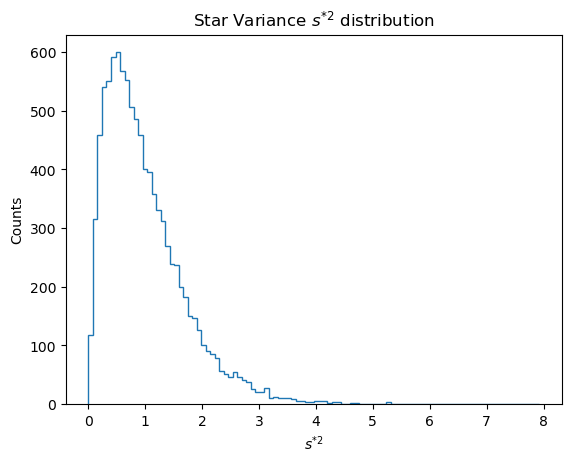

In [14]:
get_full_plot(rands_g,5,"star_var","$s^{*2}$","Star Variance $s^{*2}$ distribution",100,10000)

Requested a sample of 10 numbers!
Requested 10000 iterations!
The mean value of the distribution is: 0.9915047516650478
The standard deviation of the distribution is: 0.4703851976121066


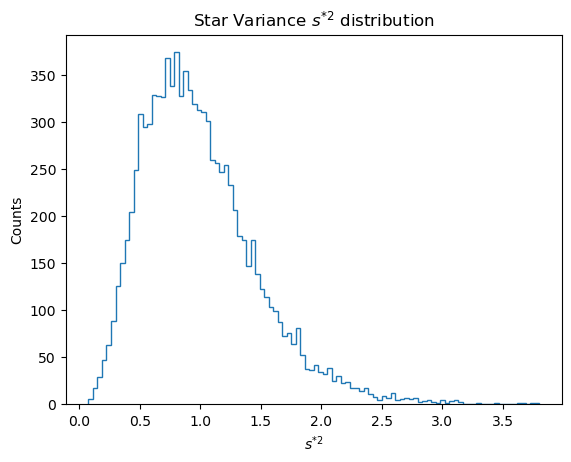

In [15]:
get_full_plot(rands_g,10,"star_var","$s^{*2}$","Star Variance $s^{*2}$ distribution",100,10000)

Requested a sample of 100 numbers!
Requested 10000 iterations!
The mean value of the distribution is: 0.992298144206957
The standard deviation of the distribution is: 0.1438161004063386


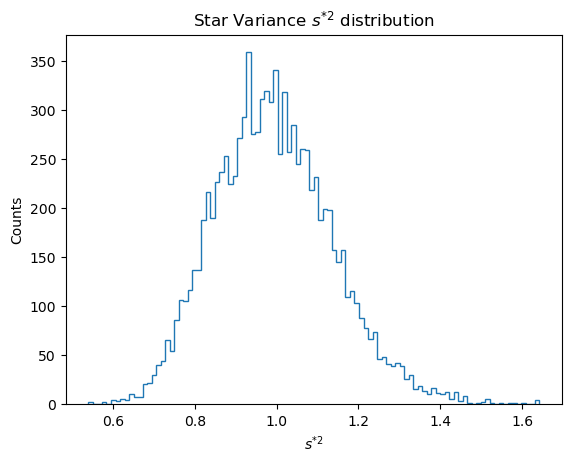

In [16]:
get_full_plot(rands_g,100,"star_var","$s^{*2}$","Star Variance $s^{*2}$ distribution",100,10000)

**Conclusion**: It can be observed that right from the start, the mean value of the $s^{*2}$ estimator's distribution is very close to the variance of the initially generated distribution. It can also be seen that the size of the sample increases, the mean value of the estimator's distribution tends to align with the variance of the initially generated distribution. Finally, as the size of the sample increases, the variance of the estimator's distribution is decreasing. 

Therefore, the $s^{*2}$ estimator is **unbiased**, **consistent** and becomes more **efficient** as the size of the sample increases. Thus it is considered a good estimator.